# Parte 2 — Feature Engineering

Construye las features que va a usar el modelo predictivo.

**Output:** `data/processed/features_train.csv` y `data/processed/features_2026.csv`

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.features import compute_elo, compute_rolling_stats, build_target, build_wc2026_features, FEATURE_COLS
from src.data_loader import load_historical_results, filter_high_stakes, load_wc2026_teams

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
PROCESSED = Path('../data/processed')
PROCESSED.mkdir(exist_ok=True)
OUTPUTS = Path('../outputs/graficos')

## 1. Carga y filtrado

In [2]:
df_raw = load_historical_results()
df_raw = df_raw.dropna(subset=['home_score', 'away_score']).copy()
df_raw['home_score'] = df_raw['home_score'].astype(int)
df_raw['away_score'] = df_raw['away_score'].astype(int)

# Para el ELO usamos TODOS los partidos (más historia = mejor calibración)
# Para el entrenamiento del modelo usamos solo partidos de alta competencia
df_hs = filter_high_stakes(df_raw)

# Excluir WC2026 del training (son partidos futuros que queremos predecir)
df_hs = df_hs[df_hs['date'].dt.year < 2026].copy()

print(f'Partidos totales en el dataset:          {len(df_raw):>7,}')
print(f'Partidos de alta competencia (<2026):    {len(df_hs):>7,}')
print(f'Torneos incluidos: {df_hs["tournament"].nunique()}')

Partidos totales en el dataset:           49,215
Partidos de alta competencia (<2026):     11,537
Torneos incluidos: 6


## 2. ELO Rating

In [3]:
# Computamos el ELO sobre TODOS los partidos para mejor calibración histórica
# pero nos quedamos con los features de alta competencia
print('Calculando ELO sobre todos los partidos...')
df_all_elo, elo_final = compute_elo(df_raw)

# Extraer ELO para los partidos de alta competencia
elo_subset = df_all_elo[df_all_elo.index.isin(df_hs.index)][['elo_home', 'elo_away', 'elo_diff']]
df_hs = df_hs.join(elo_subset)

print(f'ELO calculado. Equipos rankeados: {len(elo_final)}')
print('\nTop 15 ELO final (al terminar el dataset):')
top_elo = sorted(elo_final.items(), key=lambda x: x[1], reverse=True)[:15]
for i, (team, rating) in enumerate(top_elo, 1):
    print(f'  {i:2}. {team:<25} {rating:.0f}')

Calculando ELO sobre todos los partidos...


ELO calculado. Equipos rankeados: 333

Top 15 ELO final (al terminar el dataset):
   1. Spain                     2064
   2. Argentina                 2051
   3. France                    2018
   4. Portugal                  1947
   5. England                   1941
   6. Germany                   1938
   7. Brazil                    1937
   8. Netherlands               1937
   9. Colombia                  1925
  10. Japan                     1915
  11. Morocco                   1914
  12. Croatia                   1902
  13. Ecuador                   1890
  14. Italy                     1887
  15. Belgium                   1862


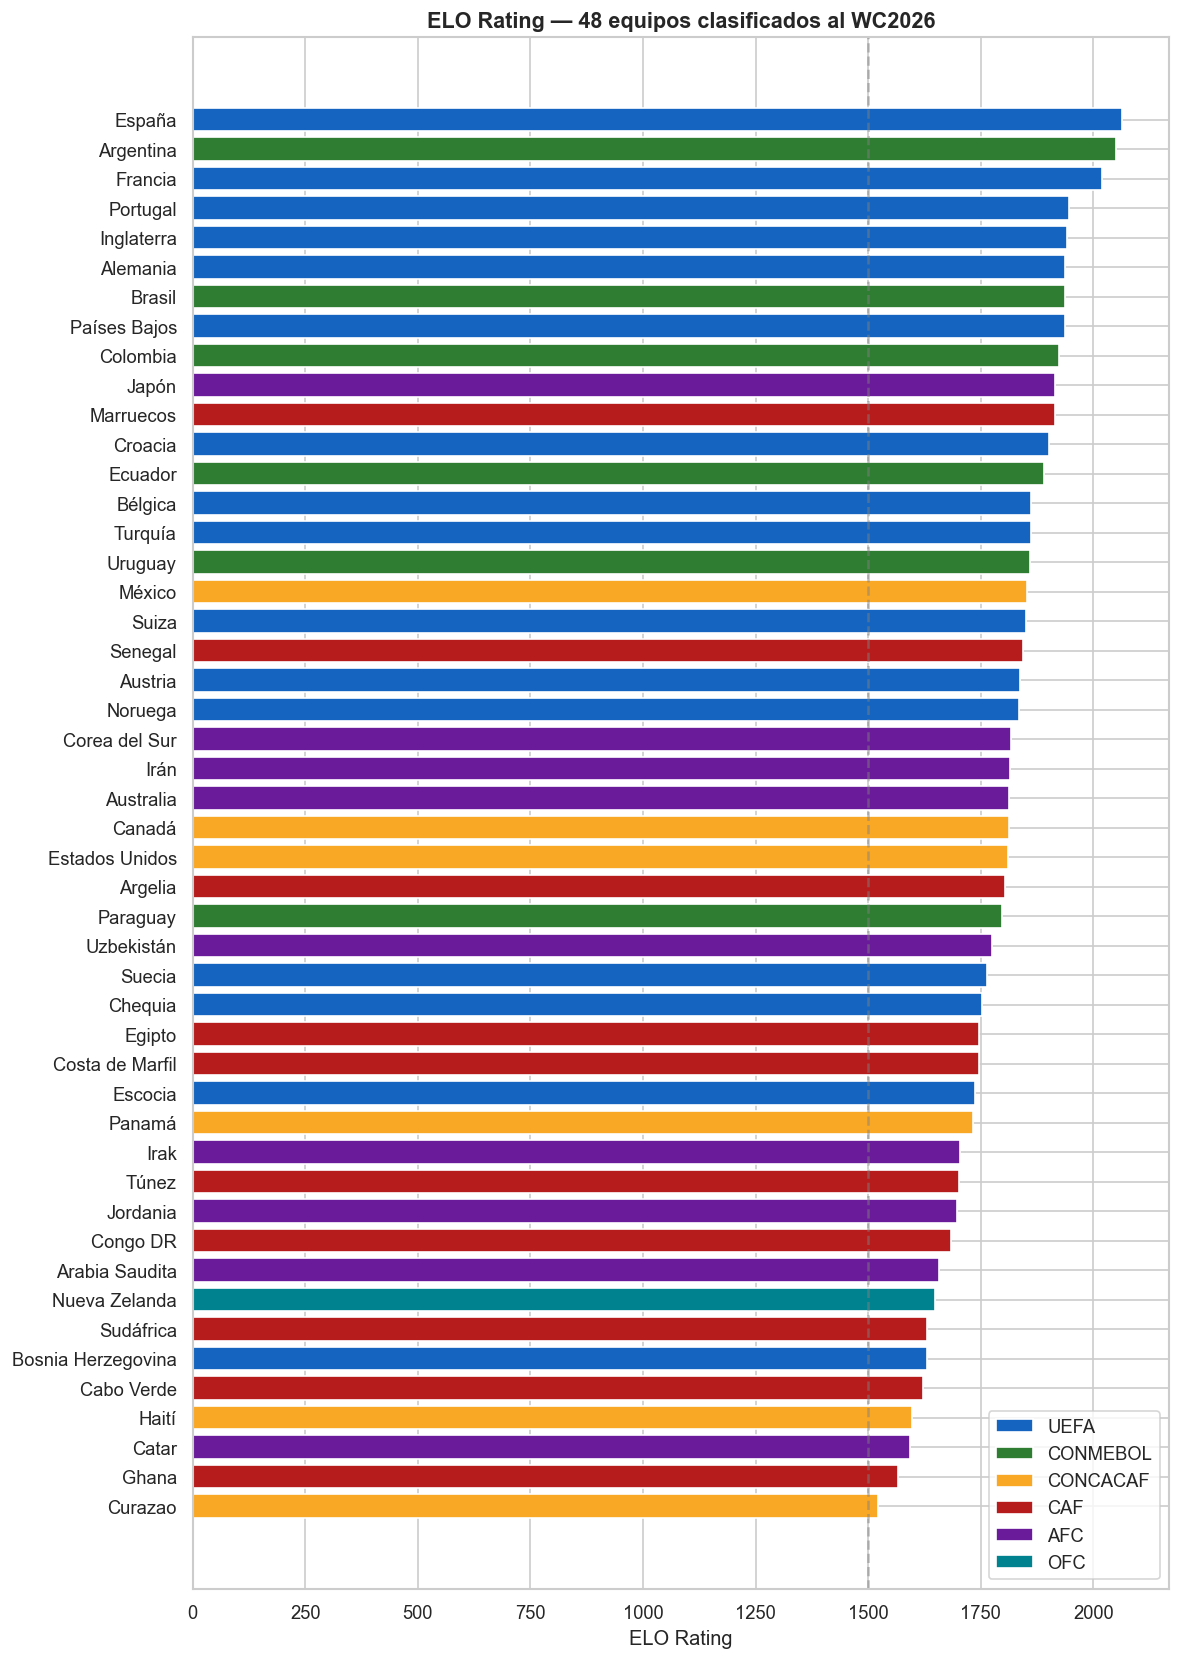

In [4]:
# Visualización: ELO de los equipos del WC2026
equipos_2026 = load_wc2026_teams()
nombre_map = {
    'Argentina': 'Argentina', 'Brasil': 'Brazil', 'Francia': 'France',
    'España': 'Spain', 'Inglaterra': 'England', 'Portugal': 'Portugal',
    'Países Bajos': 'Netherlands', 'Bélgica': 'Belgium', 'Alemania': 'Germany',
    'Uruguay': 'Uruguay', 'Colombia': 'Colombia', 'Marruecos': 'Morocco',
    'Croacia': 'Croatia', 'Suiza': 'Switzerland', 'Japón': 'Japan',
    'México': 'Mexico', 'Senegal': 'Senegal', 'Ecuador': 'Ecuador',
    'Australia': 'Australia', 'Corea del Sur': 'South Korea',
    'Estados Unidos': 'United States', 'Irán': 'Iran', 'Turquía': 'Turkey',
    'Austria': 'Austria', 'Canadá': 'Canada', 'Noruega': 'Norway',
    'Escocia': 'Scotland', 'Suecia': 'Sweden', 'Túnez': 'Tunisia',
    'Costa de Marfil': 'Ivory Coast', 'Arabia Saudita': 'Saudi Arabia',
    'Ghana': 'Ghana', 'Egipto': 'Egypt', 'Panamá': 'Panama',
    'Paraguay': 'Paraguay', 'Argelia': 'Algeria', 'Irak': 'Iraq',
    'Jordania': 'Jordan', 'Congo DR': 'DR Congo', 'Uzbekistán': 'Uzbekistan',
    'Sudáfrica': 'South Africa', 'Chequia': 'Czech Republic',
    'Catar': 'Qatar', 'Bosnia Herzegovina': 'Bosnia and Herzegovina',
    'Haití': 'Haiti', 'Curazao': 'Curaçao', 'Nueva Zelanda': 'New Zealand',
    'Cabo Verde': 'Cape Verde'
}

equipos_2026['equipo_en'] = equipos_2026['equipo'].map(nombre_map)
equipos_2026['elo'] = equipos_2026['equipo_en'].map(elo_final).fillna(1500)
equipos_2026_sorted = equipos_2026.sort_values('elo', ascending=True)

fig, ax = plt.subplots(figsize=(10, 14))
colors = ['#1565C0' if conf == 'UEFA' else '#2E7D32' if conf == 'CONMEBOL'
          else '#F9A825' if conf == 'CONCACAF' else '#B71C1C' if conf == 'CAF'
          else '#6A1B9A' if conf == 'AFC' else '#00838F'
          for conf in equipos_2026_sorted['confederacion']]
bars = ax.barh(equipos_2026_sorted['equipo'], equipos_2026_sorted['elo'],
               color=colors, edgecolor='white')
ax.axvline(1500, color='gray', linestyle='--', alpha=0.5, label='ELO base (1500)')
ax.set_title('ELO Rating — 48 equipos clasificados al WC2026', fontsize=13, fontweight='bold')
ax.set_xlabel('ELO Rating')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1565C0', label='UEFA'),
    Patch(facecolor='#2E7D32', label='CONMEBOL'),
    Patch(facecolor='#F9A825', label='CONCACAF'),
    Patch(facecolor='#B71C1C', label='CAF'),
    Patch(facecolor='#6A1B9A', label='AFC'),
    Patch(facecolor='#00838F', label='OFC'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig(OUTPUTS / 'elo_wc2026.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Rolling Stats (forma reciente)

In [5]:
print('Calculando rolling stats...')
df_hs = compute_rolling_stats(df_hs, window=10, long_window=30)
print('Listo.')

print(f'\nCobertura de features (partidos con al menos 1 feature no-nula):')
rolling_cols = ['gf_avg_home', 'ga_avg_home', 'win_rate_home',
                'gf_avg_away', 'ga_avg_away', 'win_rate_away']
for col in rolling_cols:
    pct = df_hs[col].notna().mean()
    print(f'  {col:<20} {pct:.1%} no-nulo')

Calculando rolling stats...


Listo.

Cobertura de features (partidos con al menos 1 feature no-nula):
  gf_avg_home          97.2% no-nulo
  ga_avg_home          97.2% no-nulo
  win_rate_home        95.6% no-nulo
  gf_avg_away          97.1% no-nulo
  ga_avg_away          97.1% no-nulo
  win_rate_away        95.1% no-nulo


## 4. Construcción del dataset de entrenamiento

In [6]:
df_hs = build_target(df_hs)

# Convertir neutral a int
df_hs['neutral'] = df_hs['neutral'].astype(int)

# Dataset final: solo partidos con todas las features disponibles
feature_df = df_hs[FEATURE_COLS + ['result', 'date', 'home_team', 'away_team', 'tournament']].copy()
feature_df_clean = feature_df.dropna(subset=FEATURE_COLS)

print(f'Partidos con features completas: {len(feature_df_clean):,} / {len(feature_df):,}')
print(f'\nDistribución del target:')
dist = feature_df_clean['result'].value_counts().sort_index()
labels = {0: 'Derrota home', 1: 'Empate', 2: 'Victoria home'}
for k, v in dist.items():
    print(f'  {labels[k]}: {v:,} ({v/len(feature_df_clean):.1%})')

feature_df_clean.to_csv(PROCESSED / 'features_train.csv', index=False)
print(f'\nGuardado: data/processed/features_train.csv')

Partidos con features completas: 10,636 / 11,537

Distribución del target:
  Derrota home: 3,045 (28.6%)
  Empate: 2,336 (22.0%)
  Victoria home: 5,255 (49.4%)



Guardado: data/processed/features_train.csv

## 5. Análisis de correlación de features

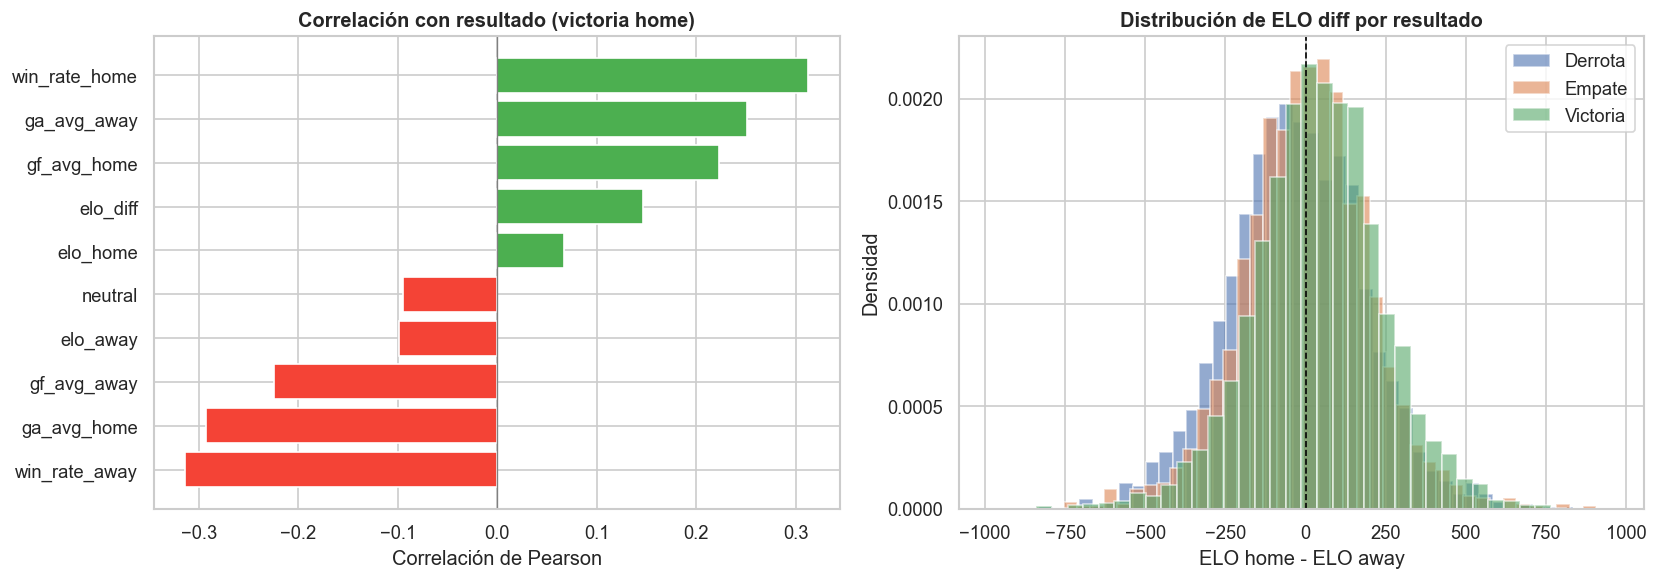

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlación features vs resultado
corr = feature_df_clean[FEATURE_COLS + ['result']].corr()['result'].drop('result').sort_values()
colors_corr = ['#F44336' if v < 0 else '#4CAF50' for v in corr]
axes[0].barh(corr.index, corr.values, color=colors_corr, edgecolor='white')
axes[0].axvline(0, color='gray', linewidth=0.8)
axes[0].set_title('Correlación con resultado (victoria home)', fontweight='bold')
axes[0].set_xlabel('Correlación de Pearson')

# Distribución ELO diff por resultado
result_labels = {0: 'Derrota', 1: 'Empate', 2: 'Victoria'}
for res, label in result_labels.items():
    subset = feature_df_clean[feature_df_clean['result'] == res]['elo_diff']
    axes[1].hist(subset, bins=40, alpha=0.6, label=label, density=True)
axes[1].set_title('Distribución de ELO diff por resultado', fontweight='bold')
axes[1].set_xlabel('ELO home - ELO away')
axes[1].set_ylabel('Densidad')
axes[1].legend()
axes[1].axvline(0, color='black', linewidth=1, linestyle='--')

plt.tight_layout()
plt.savefig(OUTPUTS / 'features_analisis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Features para el WC2026 (todos los posibles enfrentamientos)

In [8]:
# Stats más recientes de cada equipo (últimas entradas del rolling)
# Calculamos sobre todos los partidos del dataset (incluyendo 2025-2026 pre-WC)
df_all_hs = filter_high_stakes(df_raw)
df_all_hs = df_all_hs[df_all_hs['date'].dt.year < 2026].copy()
df_all_hs['home_score'] = df_all_hs['home_score'].astype(int)
df_all_hs['away_score'] = df_all_hs['away_score'].astype(int)

df_all_hs = compute_rolling_stats(df_all_hs, window=10, long_window=30)

# Para cada equipo, tomamos sus stats del último partido disponible
home_last = (df_all_hs.sort_values('date')
             .groupby('home_team')[['gf_avg_home', 'ga_avg_home', 'win_rate_home']]
             .last()
             .rename(columns={'gf_avg_home': 'gf_avg', 'ga_avg_home': 'ga_avg', 'win_rate_home': 'win_rate'})
             .reset_index().rename(columns={'home_team': 'team'}))

away_last = (df_all_hs.sort_values('date')
             .groupby('away_team')[['gf_avg_away', 'ga_avg_away', 'win_rate_away']]
             .last()
             .rename(columns={'gf_avg_away': 'gf_avg', 'ga_avg_away': 'ga_avg', 'win_rate_away': 'win_rate'})
             .reset_index().rename(columns={'away_team': 'team'}))

# Combinar home y away, promediar si aparece en los dos
team_stats_latest = (pd.concat([home_last, away_last])
                     .groupby('team')[['gf_avg', 'ga_avg', 'win_rate']]
                     .mean()
                     .reset_index())

print(f'Equipos con stats recientes: {len(team_stats_latest)}')
wc_teams_en = equipos_2026['equipo_en'].tolist()
sin_stats = [t for t in wc_teams_en if t not in team_stats_latest['team'].values]
print(f'Equipos WC2026 sin historial suficiente: {sin_stats}')

Equipos con stats recientes: 217
Equipos WC2026 sin historial suficiente: []


In [9]:
# Generar features para todos los enfrentamientos posibles entre los 48
features_2026 = build_wc2026_features(
    teams_df=equipos_2026,
    elo_final=elo_final,
    team_stats_latest=team_stats_latest,
    nombre_map=nombre_map
)

features_2026.to_csv(PROCESSED / 'features_2026.csv', index=False)
print(f'Enfrentamientos posibles generados: {len(features_2026)} ({len(features_2026)//2} pares únicos)')
print(f'Guardado: data/processed/features_2026.csv')
features_2026.head(6)

Enfrentamientos posibles generados: 2256 (1128 pares únicos)
Guardado: data/processed/features_2026.csv


,team_a,team_b,team_a_en,team_b_en,elo_home,elo_away,elo_diff,gf_avg_home,ga_avg_home,win_rate_home,gf_avg_away,ga_avg_away,win_rate_away,neutral
0,México,Sudáfrica,Mexico,South Africa,1853.865300,1631.417088,222.448212,0.80,0.40,0.516667,1.20,1.00,0.466667,1
1,Sudáfrica,México,South Africa,Mexico,1631.417088,1853.865300,-222.448212,1.20,1.00,0.466667,0.80,0.40,0.516667,1
2,México,Corea del Sur,Mexico,South Korea,1853.865300,1817.334353,36.530947,0.80,0.40,0.516667,1.95,0.70,0.566667,1
3,Corea del Sur,México,South Korea,Mexico,1817.334353,1853.865300,-36.530947,1.95,0.70,0.566667,0.80,0.40,0.516667,1
4,México,Chequia,Mexico,Czech Republic,1853.865300,1753.753930,100.111370,0.80,0.40,0.516667,1.45,1.25,0.450000,1
5,Chequia,México,Czech Republic,Mexico,1753.753930,1853.865300,-100.111370,1.45,1.25,0.450000,0.80,0.40,0.516667,1


## 7. Resumen de features

In [10]:
print('=== DATASET DE ENTRENAMIENTO ===')
print(feature_df_clean[FEATURE_COLS].describe().round(3).to_string())
print(f'\nShape: {feature_df_clean.shape}')
print(f'Features usadas: {FEATURE_COLS}')

=== DATASET DE ENTRENAMIENTO ===
        elo_home   elo_away   elo_diff  gf_avg_home  ga_avg_home  win_rate_home  gf_avg_away  ga_avg_away  win_rate_away    neutral
count  10636.000  10636.000  10636.000    10636.000    10636.000      10636.000    10636.000    10636.000      10636.000  10636.000
mean    1612.532   1599.385     13.146        1.457        1.415          0.395        1.432        1.430          0.386      0.256
std      182.972    179.102    205.256        0.721        0.880          0.180        0.693        0.880          0.177      0.436
min      978.898    978.855   -985.796        0.000        0.000          0.000        0.000        0.000          0.000      0.000
25%     1491.070   1484.170   -115.670        1.000        0.900          0.267        1.000        0.900          0.267      0.000
50%     1621.732   1612.775     16.432        1.400        1.200          0.400        1.400        1.200          0.400      0.000
75%     1741.241   1722.680    144.917     